In [2]:
using HDF5
using PyPlot
using ProgressBars
using JLD2
using Images, ImageFiltering
using Statistics
import PhysicalConstants.CODATA2018: c_0, ħ
using Unitful

In [3]:
function load_imgs(filenames, pathdir)
    imgs_atoms, imgs_bkg, imgs_dark, intensities = [], [], [], []

    for filename in filenames
        filename = pathdir*"/"*filename
        h5open(filename, "r") do file
            img_atoms = convert(Matrix{Int}, read(file["images/Vertical_Axis_Camera/in_situ_absorption/atoms"]))
            img_bkg = convert(Matrix{Int}, read(file["images/Vertical_Axis_Camera/in_situ_absorption/background"]))
            img_dark = convert(Matrix{Int}, read(file["images/Vertical_Axis_Camera/in_situ_absorption/dark"]))
            push!(imgs_atoms, img_atoms), push!(imgs_bkg, img_bkg), push!(imgs_dark, img_dark), push!(intensities, read_attribute(file["globals"], "vert_abs_img_amp_high"))
        end
    end
    return imgs_atoms, imgs_bkg, imgs_dark, intensities
end

function crop_imgs(imgs, x_crop, y_crop)
    imgs_crop = []
    for i = 1:length(imgs)
        img_crop = imgs[i][y_crop, x_crop]
        push!(imgs_crop, img_crop)
    end
    return imgs_crop
end

function compute_OD_high_low_intensity(imgs_atoms, imgs_bkg, imgs_dark, dict_set_val_sat, intensities_imgs, t_exp)
    ODs = []
    for i in 1:length(imgs_atoms)
        OD = (imgs_atoms[i] .- imgs_dark[i]) ./ (imgs_bkg[i] .- imgs_dark[i])

        OD[OD .< 0] .= NaN # Values where dark is brighter than laser/atoms are not taken into account
        OD .= -log10.(OD)
        OD[isnan.(OD)] .= 0 # Map Nan values to 0

        # For high intensity, modified OD formula
        if dict_set_val_sat[intensities_imgs[i]] >= 1
            OD .+= (imgs_bkg[i] .- imgs_atoms[i]) / (7000*t_exp[findfirst(==(intensities_imgs[i]), I_set_value)]/5e-6)
        end
        push!(ODs, OD)
    end
    return ODs
end

function mask_condensate(xc, yc, a, b, θ, x_crop, y_crop)
    mask = ones(Integer, (length(y_crop), length(x_crop)))
    X = range(0, length(y_crop)-1) .- yc
    Y = range(0, length(x_crop)-1) .- xc
    for (i, x) in enumerate(X)
        for (j, y) in enumerate(Y)
            # Rotate back
            x_hor = x*sin(θ) + y*cos(θ)
            y_hor = x*cos(θ) - y*sin(θ)
            if (x_hor/a)^2 + (y_hor/b)^2 ≤ 1
                mask[i, j] = 0
            end
        end
    end
    return mask
end

mask_condensate (generic function with 1 method)

In [4]:
pathdir = "//DyLabNAS/Data/TwoDGas/2025/07/04"
dir_names_datasets = readdir(pathdir)
dir_names_datasets = dir_names_datasets[dir_names_datasets .!= ".DS_Store"]
dir_names_datasets = dir_names_datasets[10:end]
I_set_value = [0.1882, 0.22, 0.35, 0.6, 0.8, 1.0]
sat_exp = [0.5, 1, 5, 32, 56, 65] # Estimated saturation parameter
dict_set_val_sat = Dict(I_set_value[i] => sat_exp[i] for i in eachindex(I_set_value))

τ_exp = [8, 7, 6, 5, 3, 2].*1e-6 # In s
x_crop = [1130:1730;]
y_crop = [1670:2370;]
wrong_shots = []
λ = 421e-9
ω0 = 2π*ustrip(c_0)/λ
γ = 32.7e6 # In Hz
I_sat_cst = ustrip(ħ)*γ*ω0^3 / (12π*ustrip(c_0)^2)

xc, yc, a, b, θ = 300, 370, 110, 60, 1.1;

In [4]:
if !isdir("imgs_surrounding_droplets")
    mkdir("imgs_surrounding_droplets")
end

if !isdir("imgs_surrounding_droplets/"*join(split(pathdir, "/")[6:end], "_"))
    mkdir("imgs_surrounding_droplets/"*join(split(pathdir, "/")[6:end], "_"))
end

if !isdir("imgs_surrounding_droplets/"*join(split(pathdir, "/")[6:end], "_"))
    mkdir("imgs_surrounding_droplets/"*join(split(pathdir, "/")[6:end], "_"))
end

if !isdir("imgs_surrounding_droplets/"*join(split(pathdir, "/")[6:end], "_")*"/ODs")
    mkdir("imgs_surrounding_droplets/"*join(split(pathdir, "/")[6:end], "_")*"/ODs")
end

if !isdir("imgs_surrounding_droplets/"*join(split(pathdir, "/")[6:end], "_")*"/ODs_mask")
    mkdir("imgs_surrounding_droplets/"*join(split(pathdir, "/")[6:end], "_")*"/ODs_mask")
end

if !isdir("imgs_surrounding_droplets/"*join(split(pathdir, "/")[6:end], "_")*"/neg_ODs_mask")
    mkdir("imgs_surrounding_droplets/"*join(split(pathdir, "/")[6:end], "_")*"/neg_ODs_mask")
end

# Import and crop the images

In [5]:
mask = mask_condensate(xc, yc, a, b, θ, x_crop, y_crop);

In [ ]:
imgs_atoms_crop, imgs_bkg_crop, imgs_dark_crop, intensities_imgs = [], [], [], []

for dir_name_datasets in ProgressBar(dir_names_datasets)
    files_path = readdir(pathdir*"/"*dir_name_datasets)
    imgs_atoms, imgs_bkg, imgs_dark, intensities = load_imgs(files_path, pathdir*"/"*dir_name_datasets*"/")
    push!(imgs_atoms_crop, crop_imgs(imgs_atoms, x_crop, y_crop)), push!(imgs_bkg_crop, crop_imgs(imgs_bkg, x_crop, y_crop)), push!(imgs_dark_crop, crop_imgs(imgs_dark, x_crop, y_crop)), push!(intensities_imgs, intensities)
end

0.0%┣                                                ┫ 0/6 [00:01<00:-8, -1s/it]
16.7%┣███████▏                                   ┫ 1/6 [00:44<Inf:Inf, InfGs/it]
33.3%┣███████████████▊                               ┫ 2/6 [01:26<05:42, 86s/it]
50.0%┣███████████████████████▌                       ┫ 3/6 [02:10<03:14, 65s/it]
66.7%┣███████████████████████████████▍               ┫ 4/6 [02:51<01:54, 57s/it]
83.3%┣███████████████████████████████████████▏       ┫ 5/6 [03:34<00:53, 53s/it]
100.0%┣██████████████████████████████████████████████┫ 6/6 [04:20<00:00, 52s/it]
100.0%┣██████████████████████████████████████████████┫ 6/6 [04:20<00:00, 52s/it]


In [6]:
imgs_atoms_crop, imgs_bkg_crop, imgs_dark_crop, intensities_imgs = vcat(imgs_atoms_crop...), vcat(imgs_bkg_crop...), vcat(imgs_dark_crop...), vcat(intensities_imgs...);

In [21]:
@save "Imgs_surroundings_droplet_"*join(split(pathdir, "/")[6:end], "_")*".jld2" imgs_atoms_crop imgs_bkg_crop imgs_dark_crop intensities_imgs

In [6]:
@load "Imgs_surroundings_droplet_"*join(split(pathdir, "/")[6:end], "_")*".jld2" imgs_atoms_crop imgs_bkg_crop imgs_dark_crop intensities_imgs;

In [9]:
imgs_atoms_crop_surroundings, imgs_bkg_crop_surroundings, imgs_dark_crop_surroundings = [imgs.*mask for imgs in imgs_atoms_crop], [imgs.*mask for imgs in imgs_bkg_crop], [imgs.*mask for imgs in imgs_dark_crop];

In [10]:
@save "Imgs_crop_surroundings_droplet_"*join(split(pathdir, "/")[6:end], "_")*".jld2" imgs_atoms_crop_surroundings imgs_bkg_crop_surroundings imgs_dark_crop_surroundings intensities_imgs

In [7]:
@load "Imgs_crop_surroundings_droplet_"*join(split(pathdir, "/")[6:end], "_")*".jld2" imgs_atoms_crop_surroundings imgs_bkg_crop_surroundings imgs_dark_crop_surroundings intensities_imgs;

# Compute the ODs

In [14]:
ODs_dataset = compute_OD_high_low_intensity(imgs_atoms_crop, imgs_bkg_crop, imgs_dark_crop, dict_set_val_sat, intensities_imgs, τ_exp)
ODs_dataset_surroundings = [OD.*mask for OD in ODs_dataset];

In [15]:
@save "ODs_crop_"*join(split(pathdir, "/")[6:end], "_")*"_surroundings_droplet.jld2" ODs_dataset ODs_dataset_surroundings

In [8]:
@load "ODs_crop_"*join(split(pathdir, "/")[6:end], "_")*"_surroundings_droplet.jld2" ODs_dataset ODs_dataset_surroundings;

# Save the ODs images

### ODs

In [15]:
close("all")
fig, axs = subplots()

for (i, OD) in ProgressBar(enumerate(ODs_dataset))
    img = axs.imshow(OD, cmap="plasma") #, aspect="auto"
    cb = colorbar(img)
    savefig("imgs_surrounding_droplets/"*join(split(pathdir, "/")[6:end], "_")*"/ODs/"*"$(i-1).png")
    cb.remove()
    axs.clear()
end
close("all")

0.0%┣                                              ┫ 0/300 [00:00<00:00, -0s/it]
0.3%┣▏                                         ┫ 1/300 [00:01<Inf:Inf, InfGs/it]
0.7%┣▎                                              ┫ 2/300 [00:01<05:21, 1s/it]
1.0%┣▌                                              ┫ 3/300 [00:01<03:11, 2it/s]
1.3%┣▋                                              ┫ 4/300 [00:02<02:28, 2it/s]
1.7%┣▉                                              ┫ 5/300 [00:02<02:06, 2it/s]
2.0%┣█                                              ┫ 6/300 [00:02<01:53, 3it/s]
2.3%┣█                                              ┫ 7/300 [00:02<01:45, 3it/s]
2.7%┣█▎                                             ┫ 8/300 [00:02<01:39, 3it/s]
3.0%┣█▍                                             ┫ 9/300 [00:03<01:37, 3it/s]
3.3%┣█▌                                            ┫ 10/300 [00:03<01:35, 3it/s]
3.7%┣█▊                                            ┫ 11/300 [00:03<01:32, 3it/s]
4.0%┣█▉                     

### ODs mask

In [16]:
close("all")
fig, axs = subplots()

for (i, OD) in ProgressBar(enumerate(ODs_dataset_surroundings))
    img = axs.imshow(OD, cmap="plasma") #, aspect="auto"
    cb = colorbar(img)
    savefig("imgs_surrounding_droplets/"*join(split(pathdir, "/")[6:end], "_")*"/ODs_mask/"*"$(i-1).png")
    cb.remove()
    axs.clear()
end
close("all")

0.0%┣                                              ┫ 0/300 [00:00<00:00, -0s/it]
0.3%┣▏                                         ┫ 1/300 [00:00<Inf:Inf, InfGs/it]
0.7%┣▎                                              ┫ 2/300 [00:00<02:27, 2it/s]
1.0%┣▌                                              ┫ 3/300 [00:01<01:44, 3it/s]
1.3%┣▋                                              ┫ 4/300 [00:01<01:27, 3it/s]
1.7%┣▉                                              ┫ 5/300 [00:01<01:19, 4it/s]
2.0%┣█                                              ┫ 6/300 [00:01<01:15, 4it/s]
2.3%┣█                                              ┫ 7/300 [00:01<01:12, 4it/s]
2.7%┣█▎                                             ┫ 8/300 [00:02<01:10, 4it/s]
3.0%┣█▍                                             ┫ 9/300 [00:02<01:09, 4it/s]
3.3%┣█▌                                            ┫ 10/300 [00:02<01:08, 4it/s]
3.7%┣█▊                                            ┫ 11/300 [00:02<01:07, 4it/s]
4.0%┣█▉                     

### Negative ODs

In [17]:
close("all")
fig, axs = subplots()

for (i, OD) in ProgressBar(enumerate(ODs_dataset_surroundings))
    img = axs.imshow(OD, cmap="bone", vmin=-0.2, vmax=0) #, aspect="auto"
    cb = colorbar(img)
    savefig("imgs_surrounding_droplets/"*join(split(pathdir, "/")[6:end], "_")*"/neg_ODs_mask/"*"$(i-1).png")
    cb.remove()
    axs.clear()
end
close("all")

0.0%┣                                              ┫ 0/300 [00:00<00:00, -0s/it]
0.3%┣▏                                         ┫ 1/300 [00:00<Inf:Inf, InfGs/it]
0.7%┣▎                                              ┫ 2/300 [00:01<02:54, 2it/s]
1.0%┣▌                                              ┫ 3/300 [00:01<01:57, 3it/s]
1.3%┣▋                                              ┫ 4/300 [00:01<01:38, 3it/s]
1.7%┣▉                                              ┫ 5/300 [00:01<01:29, 3it/s]
2.0%┣█                                              ┫ 6/300 [00:01<01:23, 4it/s]
2.3%┣█                                              ┫ 7/300 [00:02<01:19, 4it/s]
2.7%┣█▎                                             ┫ 8/300 [00:02<01:16, 4it/s]
3.0%┣█▍                                             ┫ 9/300 [00:02<01:13, 4it/s]
3.3%┣█▌                                            ┫ 10/300 [00:02<01:11, 4it/s]
3.7%┣█▊                                            ┫ 11/300 [00:02<01:10, 4it/s]
4.0%┣█▉                     

# Plot I(s) in regions where OD <0

In [9]:
Iatoms_surrounding_drop, Ibkg_surrounding_drop, Idark_surrounding_drop = zeros(length(ODs_dataset)), zeros(length(ODs_dataset)), zeros(length(ODs_dataset))

for i in ProgressBar(1:length((imgs_atoms_crop_surroundings)))
    if i ∉ wrong_shots
        Convertion_factor = (0.85 * 0.107 * τ_exp[findfirst(==(intensities_imgs[i]), I_set_value)])
        # Iatoms_surrounding_drop[i] = sum(imgs_atoms_crop_surroundings[i][ODs_dataset_surroundings[i] .< 0])/Convertion_factor
        # Ibkg_surrounding_drop[i] = sum(imgs_bkg_crop_surroundings[i][ODs_dataset_surroundings[i] .< 0])/Convertion_factor
        # Idark_surrounding_drop[i] = sum(imgs_dark_crop_surroundings[i][ODs_dataset_surroundings[i] .< 0])/Convertion_factor
        Iatoms_surrounding_drop[i] = sum(imgs_atoms_crop_surroundings[i])/Convertion_factor
        Ibkg_surrounding_drop[i] = sum(imgs_bkg_crop_surroundings[i])/Convertion_factor
        Idark_surrounding_drop[i] = sum(imgs_dark_crop_surroundings[i])/Convertion_factor
    end
end

0.0%┣                                             ┫ 0/300 [00:02<-8:-48, -2s/it]
0.3%┣▏                                         ┫ 1/300 [00:02<Inf:Inf, InfGs/it]
1.7%┣▉                                              ┫ 5/300 [00:02<02:43, 2it/s]
3.3%┣█▌                                            ┫ 10/300 [00:02<01:13, 4it/s]
5.3%┣██▌                                           ┫ 16/300 [00:02<00:44, 6it/s]
7.3%┣███▍                                          ┫ 22/300 [00:02<00:31, 9it/s]
9.3%┣████▏                                        ┫ 28/300 [00:02<00:24, 11it/s]
11.3%┣█████                                       ┫ 34/300 [00:02<00:20, 13it/s]
13.0%┣█████▊                                      ┫ 39/300 [00:03<00:17, 15it/s]
15.0%┣██████▋                                     ┫ 45/300 [00:03<00:15, 17it/s]
17.0%┣███████▌                                    ┫ 51/300 [00:03<00:13, 19it/s]
18.7%┣████████▏                                   ┫ 56/300 [00:03<00:12, 20it/s]
20.3%┣█████████             

In [10]:
Iatoms_surrounding_drop_per_sat, Ibkg_surrounding_drop_per_sat, Idark_surrounding_drop_per_sat = zeros((length(sat_exp), Integer(length(Iatoms_surrounding_drop)/length(sat_exp)))), zeros((length(sat_exp), Integer(length(Iatoms_surrounding_drop)/length(sat_exp)))), zeros((length(sat_exp), Integer(length(Iatoms_surrounding_drop)/length(sat_exp))))

for i in 1:length(Iatoms_surrounding_drop)
    if i ∉ wrong_shots
        idx = findfirst(==(intensities_imgs[i]), I_set_value)
        # println("$idx, $(floor(Int64, ((i-1)%(length(Iatoms_surrounding_drop)/length(sat_exp))+1)))")
        Iatoms_surrounding_drop_per_sat[idx, floor(Int64, ((i-1)%(length(Iatoms_surrounding_drop)/length(sat_exp))+1))] = Iatoms_surrounding_drop[i]
        Ibkg_surrounding_drop_per_sat[idx, floor(Int64, ((i-1)%(length(Iatoms_surrounding_drop)/length(sat_exp))+1))] = Ibkg_surrounding_drop[i]
        Idark_surrounding_drop_per_sat[idx, floor(Int64, ((i-1)%(length(Iatoms_surrounding_drop)/length(sat_exp))+1))] = Idark_surrounding_drop[i]
    end
end

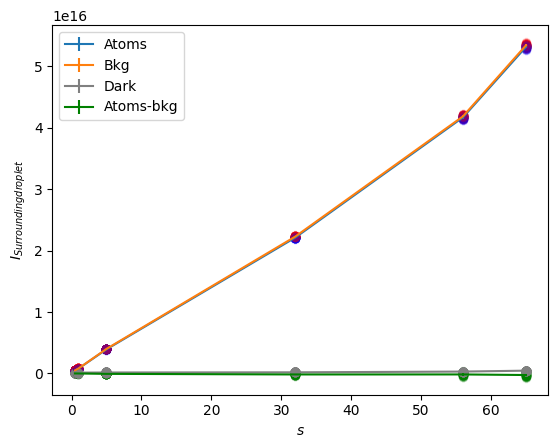

In [11]:
close("all")
fig = subplots()

errorbar(sat_exp, vec(mean(Iatoms_surrounding_drop_per_sat, dims = 2)), yerr=vec(std(Iatoms_surrounding_drop_per_sat, dims = 2)), label="Atoms")
errorbar(sat_exp, vec(mean(Ibkg_surrounding_drop_per_sat, dims = 2)), yerr=vec(std(Ibkg_surrounding_drop_per_sat, dims = 2)), label="Bkg")
errorbar(sat_exp, vec(mean(Idark_surrounding_drop_per_sat, dims = 2)), yerr=vec(std(Idark_surrounding_drop_per_sat, dims = 2)), label="Dark", color="grey")
errorbar(sat_exp, vec(mean(Iatoms_surrounding_drop_per_sat, dims = 2))-vec(mean(Ibkg_surrounding_drop_per_sat, dims = 2)), yerr=vec(std(Iatoms_surrounding_drop_per_sat-Ibkg_surrounding_drop_per_sat, dims = 2)), label="Atoms-bkg", color="green")

for (i, OD) in enumerate(ODs_dataset)
    scatter(dict_set_val_sat[intensities_imgs[i]], Iatoms_surrounding_drop[i], color="b", alpha = 0.1)
    scatter(dict_set_val_sat[intensities_imgs[i]], Ibkg_surrounding_drop[i], color="r", alpha = 0.1)
    scatter(dict_set_val_sat[intensities_imgs[i]], Iatoms_surrounding_drop[i]-Ibkg_surrounding_drop[i], color="g", alpha = 0.1)
    scatter(dict_set_val_sat[intensities_imgs[i]], Idark_surrounding_drop[i], color="grey")
end

xlabel(L"s")
ylabel(L"I_{Surrounding droplet}")

legend()

# pygui(true); show();
pygui(false);

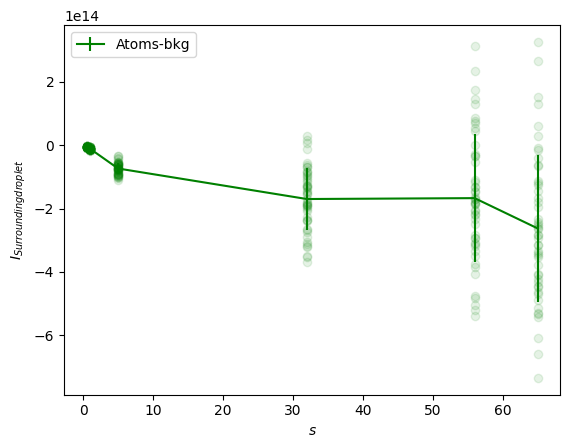

In [12]:
close("all")
fig = subplots()

errorbar(sat_exp, vec(mean(Iatoms_surrounding_drop_per_sat, dims = 2))-vec(mean(Ibkg_surrounding_drop_per_sat, dims = 2)), yerr=vec(std(Iatoms_surrounding_drop_per_sat-Ibkg_surrounding_drop_per_sat, dims = 2)), label="Atoms-bkg", color="green")

for (i, OD) in enumerate(ODs_dataset)
    scatter(dict_set_val_sat[intensities_imgs[i]], Iatoms_surrounding_drop[i]-Ibkg_surrounding_drop[i], color="g", alpha = 0.1)
end

xlabel(L"s")
ylabel(L"I_{Surrounding droplet}")

legend()

# pygui(true); show();
pygui(false);

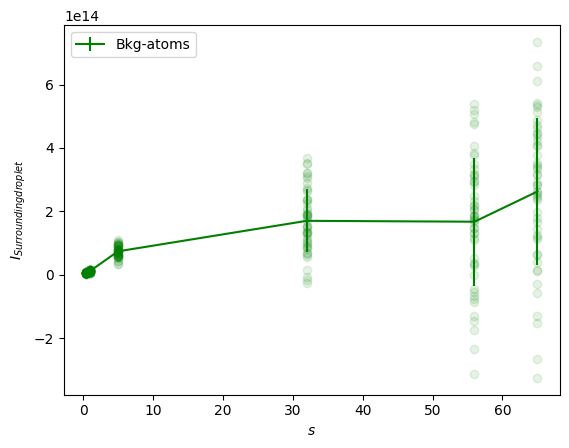

In [13]:
close("all")
fig = subplots()

errorbar(sat_exp, vec(mean(Ibkg_surrounding_drop_per_sat, dims = 2))-vec(mean(Iatoms_surrounding_drop_per_sat, dims = 2)), yerr=vec(std(Iatoms_surrounding_drop_per_sat-Ibkg_surrounding_drop_per_sat, dims = 2)), label="Bkg-atoms", color="green")

for (i, OD) in enumerate(ODs_dataset)
    scatter(dict_set_val_sat[intensities_imgs[i]], Ibkg_surrounding_drop[i]-Iatoms_surrounding_drop[i], color="g", alpha = 0.1)
end

xlabel(L"s")
ylabel(L"I_{Surrounding droplet}")

legend()

# pygui(true); show();
pygui(false);

# Brouillons

In [ ]:
# close("all")
# figure()
# img = imshow(imgs_atoms_crop[5]-imgs_bkg_crop[5])
# colorbar(img)
# pygui(true); show();


# ODs = compute_OD_high_low_intensity(imgs_atoms_crop, imgs_bkg_crop, imgs_dark_crop, dict_set_val_sat, intensities_imgs, τ_exp);

# close("all")
# fig, axs = subplots(1, 4, figsize=(15, 5))
# img = axs[1].imshow(ODs[5])
# # colorbar(img)

# xc, yc, a, b, θ = 310, 350, 110, 60, 1.1;
# mask = mask_ellipse(xc, yc, a, b, θ, x_crop, y_crop)

# axs[2].imshow(ODs[5].*(1 .-mask))

# axs[3].imshow(ODs[5].*mask)

# OD_mask = ODs[5].*mask

# axs[4].imshow(OD_mask .* (OD_mask .< 0))


# # pygui(true); show();
# pygui(false)